# 02 · IDEAgent — Agentic Quality-Diversity Search for Research Idea Generation

**Paper:** Gumma, Majumder, Sinhahajari, Poria (NTU DeCLaRe). arXiv 2607.22375 (`papers/2607.22375v1.pdf`).

**Code status:** the authors' repository (`github.com/declare-lab/IDEAgent`, commit `1213761`) is a faithful Python implementation and ships the 32-topic background corpus. This notebook **drives the vendored repo directly** (`notebooks/vendor/IDEAgent`, gitignored; re-fetched by the setup cell) after a small patch (`notebooks/patches/ideagent_openrouter.patch`) that (a) removes a stray constructor kwarg that crashes the shipped runner, (b) adds `base_url` support so every role can run through OpenRouter, and (c) controls hidden reasoning on reasoning models so long outputs are not truncated. Two things the paper defines but the repo does not ship — **Yield (Alg. 2)** and **greedy max–min topic selection (Alg. 1)** — are implemented in `notebooks/ideagent_extras.py` on top of the repo's exact maximum-clique routine, together with the Table-1/Fig-2 views and the two figures.

All roles use the project's OpenRouter model (`.env`). The paper used gpt-5.6 / gemini-3.x, so absolute scores differ; the mechanisms are what is under test.

| § | Building block | Paper ref | Repo code |
|---|---|---|---|
| 1 | Background corpus X and topic context | Sec. 3.1, Sec. 4 | `ideagent/data.py` |
| 2 | Stage I→II→III control flow | Fig. 1 (left), eq. (3) | `ideagent_extras.stage_flow_diagram` |
| 3 | Ideator | Sec. 3.2 | `agents.IdeatorAgent.open`, `prompts.op_free` |
| 4 | Stenographer σ(I) = (p, m, v, a, e) | eq. (1) | `signature.extract_signature` |
| 5 | Quality Evaluator NB / C / F (0–100) | Sec. 3.2 | `agents.QualityAgent.evaluate` |
| 6 | Soundness Panel M samples, severe/disputed/invalid | eq. (2) | `agents.evaluate_soundness_multi`, `generation_loop._soundness_panel_status` |
| 7 | Diversity Judge D_I + duplicate list | Sec. 3.2, Table 4 | `diversity_judge.judge_diversity` |
| 8 | Stores A/Q/H/R, gate G (eq. 4), routing cases 1–4 | Sec. 3.3 Stage II | `archive.Archive.consider`, `Thresholds` |
| 9 | Q_b = 0.7N + 0.2S + 0.1C, archive replacement | eq. (5) | `archive.Candidate.outranks` |
| 10 | Critic → repair | Sec. 3.3 Stage II | `agents.CriticAgent.focused_review`, `prompts.op_critic_revision` |
| 11 | The same repair loop driven by a **live pi coding agent** | Sec. 3.3 Stage II | `common.run_pi` + `loop._evaluate` / `Archive.consider` |
| 12 | Refinement + blinded position-swapped comparison | Sec. 3.3 Stage III | `GenerationLoop._relative_nb_comparison`, `Archive.consider_accepted_refinement` |
| 13 | Yield (max clique), successful topics, CST | Alg. 2, eq. (7) | `ideagent_extras.yield_count` (+ repo `_maximum_clique`) |
| 14 | Greedy max–min topic selection | Alg. 1 | `ideagent_extras.greedy_maxmin_topics` |
| 15 | End-to-end run on **two topics** (B=5, C_A=5, K_aux=2, M=5) | Sec. 3.3, Sec. 6.1 | `GenerationLoop.run_topic` |
| 16 | Baselines: Stateless, Sequential-Memory, One-Shot | Sec. 6.2 | `ideagent/sequential_memory_baseline.py`, `baselines/simple/pipeline.py` |
| 17 | Table-1-style comparison under the external judges + CST | Sec. 5, Table 1, eq. (7) | `quality_eval`, `diversity_eval`, `ideagent_extras.table1` |
| 18 | Yield surface over (NB k, S l) | Fig. 2 / Fig. 4 | `ideagent_extras.yield_surface_by_method` |
| 19 | Lineage graph of the final run | Fig. 1 (right) | `ideagent_extras.lineage_graph` |

In [1]:
import os, sys, json, time, copy, shutil, html, dataclasses, hashlib
os.environ.setdefault("TQDM_DISABLE", "1")   # the repo's evaluators print tqdm bars; keep the notebook readable
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
common.banner()
# --- vendor + patch the authors' repo at the pinned commit
VENDOR = common.ensure_repo("https://github.com/declare-lab/IDEAgent", "121376126a4864ee5436ea5a23ffc8dc0f7842c5", "IDEAgent")
applied = common.apply_patch("patches/ideagent_openrouter.patch", VENDOR)
print("vendored at", VENDOR, "| patch applied now:", applied)
sys.path.insert(0, str(VENDOR))
import ideagent_extras as X
from ideagent.data import load_raw_topic_groups, parse_paper, build_background_context, truncate_by_tokens_rough
from ideagent.agents import IdeatorAgent, CriticAgent, QualityAgent, evaluate_soundness_multi
from ideagent.signature import extract_signature, SIGNATURE_FIELDS, SemanticSignature
from ideagent.diversity_judge import judge_diversity, DiversityVerdict
from ideagent.archive import Archive, Thresholds, Candidate, EARLY_WEIGHTS, LATE_WEIGHTS, ACCEPTED, REPLACED, QUALIFIED_RETIRED, KEEP_ACCEPTED, REJECT_DUPLICATE, REPAIR_QUEUED, REPAIR_RETAINED, REJECT_UNSOUND, REJECT_EVAL_FAIL
from ideagent.generation_loop import Config, GenerationLoop, _soundness_panel_status, _score_map
from ideagent.prompts import op_free, op_free_baseline, op_critic_revision, build_repair_critic_user, REPAIR_CRITIC_SYSTEM, RELATIVE_NB_SYSTEM
OUT = OUTPUT_DIR / "ideagent"; OUT.mkdir(exist_ok=True)

def details(title, text, limit=20000):
    "Collapsed <details> block: used to keep full artefacts (ideas, JSON dumps) in the notebook without flooding it."
    display(HTML(f"<details><summary><b>{html.escape(title)}</b></summary>"
                 f"<pre style='white-space:pre-wrap;font-size:11px;line-height:1.35'>{html.escape(text[:limit])}"
                 f"{'' if len(text) <= limit else chr(10) + '… [truncated]'}</pre></details>"))

def jdump(obj, limit=100000):
    return json.dumps(obj, indent=1, ensure_ascii=False, default=str)[:limit]
print("pi coding agent available:", common.pi_available())

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

vendored at /mnt/berstorage/RCP/rcp-platform/notebooks/vendor/IDEAgent | patch applied now: False
pi coding agent available: True


## 1 · Background corpus X and topic context (Sec. 3.1, Sec. 4)

Each topic is a set of 5–8 background papers (title, abstract, introduction, conclusion) that "could have influenced" several published papers. The Ideator only ever sees this closed corpus. Sections 3–14 walk one topic (`cs.AI-002`) through every component; the end-to-end run in §15 uses **two** topics from different domains so that Yield and the successful-topic indicator (Sec. 5) have more than one sample.

In [2]:
TOPIC_PATH = str(VENDOR / "data" / "bkgd_papers.jsonl")
TOPICS = load_raw_topic_groups(TOPIC_PATH)
print(len(TOPICS), "topics;", sorted({t["domain_id"] for t in TOPICS}))
display(df([{"topic_id": t["topic_id"], "domain": t["domain_id"], "name": t.get("topic_name", ""), "#background": len(t["background_papers"]), "#target": len(t["target_papers"])} for t in TOPICS]).head(12))

def background_of(topic, max_tokens=12000):
    return truncate_by_tokens_rough(build_background_context([parse_paper(p) for p in topic["background_papers"]]), max_tokens)

TOPIC = TOPICS[1]                                                   # cs.AI-002, the walkthrough topic
TOPIC2 = next(t for t in TOPICS if t["domain_id"] == "cs.RO")       # a second domain for the end-to-end run
TOPIC_IDX = {t["topic_id"]: i for i, t in enumerate(TOPICS)}
BACKGROUND = background_of(TOPIC)
BG = {TOPIC["topic_id"]: BACKGROUND, TOPIC2["topic_id"]: background_of(TOPIC2)}
for t in (TOPIC, TOPIC2):
    print(f"{t['topic_id']:>10} — {t.get('topic_name','')}: {len(t['background_papers'])} papers, "
          f"context ≈ {len(BG[t['topic_id']].split())} words")
print()
print(BACKGROUND[:700], "...")

32 topics; ['cs.AI', 'cs.CL', 'cs.CV', 'cs.DC', 'cs.IR', 'cs.LG', 'cs.RO', 'cs.SE']


,topic_id,domain,name,#background,#target
0,cs.AI-001,cs.AI,Scaling LLM Reasoning via Reinforcement Learning,8,5
1,cs.AI-002,cs.AI,Scaling LLM Reasoning via Reinforcement Learning,8,5
2,cs.AI-003,cs.AI,Reasoning in Large Language Models,5,3
3,cs.AI-004,cs.AI,Reinforcement Learning for Advanced AI Reasoning,6,3
4,cs.CL-012,cs.CL,Deep Learning Representation and Analysis,8,3
5,cs.CL-026,cs.CL,Scaling Laws for Neural Networks,8,4
6,cs.CL-034,cs.CL,Knowledge Localization and Model Editing,7,3
7,cs.CL-036,cs.CL,Efficient Attention Mechanisms and KV Cache Op...,8,3
8,cs.CL-040,cs.CL,Multilingual Multitask Language Understanding ...,6,3
9,cs.CL-047,cs.CL,Adversarial Robustness of LLM Safety Alignment,6,3


 cs.AI-002 — Scaling LLM Reasoning via Reinforcement Learning: 8 papers, context ≈ 7709 words
 cs.RO-005 — Diffusion Models for End-to-End Autonomous Driving: 8 papers, context ≈ 8063 words

<BACKGROUND>
[Paper 1]
Paper ID: 2402.03300
Title: DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models
Text:
Title: DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models

Abstract: Mathematical reasoning poses a significant challenge for language models due to its complex and structured nature. In this paper, we introduce DeepSeekMath 7B, which continues pre-training DeepSeek-Coder-Base-v1.5 7B with 120B math-related tokens sourced from Common Crawl, together with natural language and code data. DeepSeekMath 7B has achieved an impressive score of 51.7% on the competition-level MATH benchmark without relying on external toolkits and  ...


### Build the agents (one OpenRouter client per role, as in `scripts/run_ideagent.py`)

The repo builds five role clients (`ideator`, `critic`, `quality`, `steno`, `judge`) from the YAML; here they all point at `RCP_MODEL`. The `GenerationLoop` object below holds them and is reused by §3–§12; §15 builds one fresh loop per topic so the two searches can run side by side.

In [3]:
ic, ikw = X.make_client(max_new_tokens=5000, tag="ideator")
cc, ckw = X.make_client(max_new_tokens=2500, tag="critic")
qc, qkw = X.make_client(max_new_tokens=3000, tag="quality+soundness")
sc, skw = X.make_client(max_new_tokens=1024, tag="steno")
jc, jkw = X.make_client(max_new_tokens=2048, tag="judge")
SOUND_N = 3 if QUICK else 5                      # paper: M = 5 (Sec. 3.2, footnote)
cfg = Config(input_jsonl=TOPIC_PATH, output_dir=str(OUT / "demo"), max_budget=2 if QUICK else 3,
             soundness_n=SOUND_N, soundness_fatal_min_votes=(SOUND_N // 2) + 1, diversity_D=60, accepted_capacity=3,
             repair_capacity=1, repair_attempt_limit=1, accepted_refinement_limit=1, auxiliary_attempt_limit=1, consolidate_every=12)
T = cfg.thresholds()
loop = GenerationLoop(config=cfg, ideator=IdeatorAgent(role="ideator", client=ic, gen_kwargs=ikw), critic=CriticAgent(role="critic", client=cc, gen_kwargs=ckw),
                      quality=QualityAgent(role="quality", client=qc, gen_kwargs=qkw), steno_client=sc, steno_gen_kwargs=skw, judge_client=jc, judge_gen_kwargs=jkw)
print("thresholds:", T)
print("early / late Q_b weights:", EARLY_WEIGHTS, LATE_WEIGHTS)

thresholds: Thresholds(soundness_floor=60.0, soundness_fatal_threshold=3, soundness_fatal_min_votes=3, nb_min=60, clarity_min=60, diversity_D=60, repair_margin=20, repair_diversity_D=45)
early / late Q_b weights: QualityWeights(non_obviousness=0.7, soundness=0.2, clarity=0.1) QualityWeights(non_obviousness=0.4, soundness=0.4, clarity=0.2)


## 2 · The search procedure at a glance — Stage I → II → III (Fig. 1 left, eq. 3)

$$I_b^{(0)} \longrightarrow [\textsc{Repair}] \longrightarrow [\textsc{Refine}] \longrightarrow I_{b+1}^{(0)},\qquad b=1,\dots,B$$

The search completes the bounded lineage of one seed before generating the next; the bracketed operations are conditional. The diagram below is drawn from the repo's actual control flow (the gate constants come from the `Thresholds` object built above), and the rest of the notebook walks it block by block.

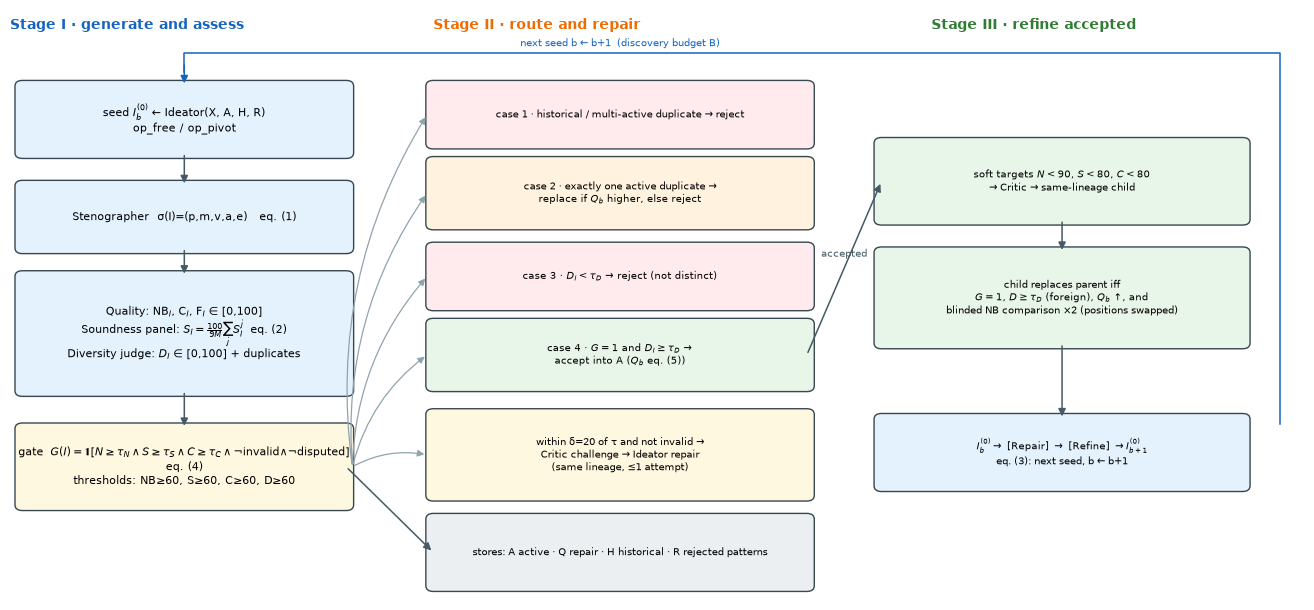

In [4]:
fig = X.stage_flow_diagram(T); plt.show()

## 3 · Ideator (Sec. 3.2)

"The Ideator is the core generator agent that reads a background corpus X to generate a complete seed idea from scratch." The opening directive `op_free` asks for a novel, sound idea distinct from the archive (empty here) and from the rejected-pattern summary. Note the two standing pressure blocks (`NON_OBVIOUSNESS_PRESSURE`, `SOUND_BY_CONSTRUCTION`) and the "restate the complete idea" rule that makes every draft independently evaluable.

In [5]:
print(op_free([], "")[:900], "...")

Propose a NOVEL, non-obvious, and SOUND research idea for this problem space. It must not be a direct combination, extension, or ablation of the background papers. You are free to choose any problem and any mechanism (it may combine several parts of the pipeline) -- just make it genuinely distinct from what already exists.

NON-OBVIOUSNESS IS A FLOOR, NOT A BOX TO CHECK. A superficially strong score (even 80/100) does not establish that the central move is harder to anticipate than another strong idea. Identify the most obvious competent approach to the same failure mode, then make the proposed causal lever genuinely discontinuous from that approach. Extra components, implementation detail, jargon, and combinations of familiar techniques do not create non-obviousness. The conceptual leap must remain clear after all decorative details are removed, and it must remain sound rather than borr ...


In [6]:
t0 = time.time()
IDEA = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_free([], ""))
print(f"{len(IDEA)} chars in {time.time()-t0:.0f}s\n")
print(IDEA[:1800], "\n...")
details(f"Ideator draft i1 — complete markdown ({len(IDEA)} chars)", IDEA)

7905 chars in 25s

The background papers all share a fundamental assumption: the reward signal for RL training is binary correctness of the final answer. Whether it's GRPO, DAPO, Dr. GRPO, or vanilla PPO, the entire training signal reduces to "did the model output the right final number or not." Everything else—response length shaping, clip ranges, sampling strategies—is patchwork on top of this single scalar signal.

Here is the proprietary insight the field is ignoring: **the correctness signal can be decomposed into two orthogonal components—the problem's verifiable structure and the model's reasoning path—and only the former should drive RL updates.** The current RL pipeline conflates these, which is exactly why long-CoT training produces overthinking, why response length spuriously correlates with reward, and why data selection (LIMR) behaves unpredictably across model scales.

**The idea: a dual-signal RL objective that decouples "did you solve it" from "how did you solve it," us

## 4 · Stenographer σ(I) = (p, m, v, a, e) — eq. (1)

$$\sigma(I) = (p_I,\, m_I,\, v_I,\, a_I,\, e_I)$$

problem, central mechanism, novel value addition over the background literature, key assumptions, expected measurable effect. Each field is capped in characters; this compact quintuple — not the full text — is what every later comparison (diversity judgment, archive memory, avoid-blocks) uses.

In [7]:
print("fields:", SIGNATURE_FIELDS)
SIG = extract_signature(IDEA, idea_id="i1", client=sc, gen_kwargs=skw, char_cap=cfg.signature_char_cap)
for f in SIGNATURE_FIELDS: print(f"{f:>16}: {getattr(SIG, f)}")
print("\ncompact form used in prompts:\n", SIG.compact())
details("Stenographer output — signature.to_json()", jdump(SIG.to_json()))

fields: ('problem', 'core_mechanism', 'novel_move', 'key_assumption', 'expected_effect')


         problem: Current reasoning RL uses a single binary correctness reward per problem, conflating problem difficulty with solution path, which drives overthinking, spurious length-reward correlations, and non-transferable data selection.
  core_mechanism: Pre-RL estimate each problem's difficulty via a Rasch IRT model fitted on the base model's solve rates, then scale the binary correctness reward by a monotone increasing weight of that frozen difficulty score during RL.
      novel_move: Replace the monolithic binary reward with a problem-specific weight inferred from the model's own pre-training success distribution, converting RL from maximizing correctness to maximizing improvability.
  key_assumption: A problem's pre-RL solve rate from the base model is a stable, sufficient statistic for its genuine reasoning difficulty that generalizes across RL training.
 expected_effect: Eliminates overthinking on easy problems, removes GRPO's length bias toward long incorrect responses, a

## 5 · Quality Evaluator — NB, C, F on 0–100 (Sec. 3.2)

One structured call scores the rubrics. Non-obviousness (NB$_I$) measures whether the central value addition needs a genuine conceptual leap; mechanism clarity (C$_I$) whether the causal steps from intervention to expected effect are well described; feasibility (F$_I$) is measured but **excluded from the gate** ("an ambitious, sound mechanism may be valuable before it is immediately executable"). The parsing/tiering helpers are pure Python.

In [8]:
loop.quality.reset_for_topic(prior_final_idea_cores=[])
VQ = loop.quality.evaluate(prev_critic_turn="", latest_ideator_turn=IDEA, current_final_idea_core=None)
SCORES = _score_map(VQ.get("rubric_assessment") or [])
display(df([{"rubric": r.get("id"), "score": r.get("score"), "evidence": str(r.get("evidence", ""))[:160]} for r in VQ.get("rubric_assessment", [])]))
print({k: SCORES.get(k) for k in ("non_obviousness", "mechanism_clarity", "feasibility")}, "| primary bottleneck:", VQ.get("primary_bottleneck"))
details("Quality Evaluator — complete rubric JSON", jdump(VQ))

,rubric,score,evidence
0,prior_episode_overlap,0,
1,source_boundedness/narrowness,25,The idea uses the Rasch/IRT model as a specifi...
2,motivation_distinctness,85,The ideator explicitly reframes the core probl...
3,non_obviousness,78,The core move—treating correctness as a statis...
4,feasibility,65,The ideator specifies a concrete pipeline: pre...
5,mechanism_clarity,75,The causal chain is well-specified: (1) pre-RL...


{'non_obviousness': 78, 'mechanism_clarity': 75, 'feasibility': 65} | primary bottleneck: source_boundedness/narrowness


## 6 · Soundness Panel — eq. (2)

$$S_I=\frac{100}{9M}\sum_{j=1}^{M} S_I^{j}$$

with $M$ independent 0–9 judgments of logical/mathematical consistency (the repo runs them in parallel with one call each). A judgment is **severe** when $S_I^j \le 3$; at least one severe vote marks the idea *disputed* (not directly accepted, but repairable), three or more make it *invalid* (discarded).

In [9]:
show_source(_soundness_panel_status)
PANEL = evaluate_soundness_multi(IDEA, client=qc, gen_kwargs=qkw, n=SOUND_N)
VOTES = [r["score"] for r in PANEL]
S100 = sum(VOTES) / len(VOTES) * 100 / 9
fatal, disputed, n_severe = _soundness_panel_status(VOTES, fatal_threshold=T.soundness_fatal_threshold, fatal_min_votes=T.soundness_fatal_min_votes)
print(f"votes={VOTES} → S_I={S100:.1f}/100 | severe votes={n_severe} | disputed={disputed} | invalid={fatal}")
display(df([{"juror": j, "score": r["score"], "severe (≤3)": r["score"] <= T.soundness_fatal_threshold, "rationale": r["rationale"][:220]} for j, r in enumerate(PANEL, 1)]))
details("Soundness panel — all rationales in full", jdump(PANEL))

**_soundness_panel_status**

```python
def _soundness_panel_status(
    samples: list[int], *, fatal_threshold: int, fatal_min_votes: int,
) -> tuple[bool, bool, int]:
    """Return (hard_fatal, disputed, severe_vote_count).

    A partial/empty panel still fails closed through eval_ok; an empty panel is also marked fatal.
    A non-consensus severe objection is preserved as a repairable dispute rather than ignored or
    allowed directly through the acceptance gate.
    """

    if not samples:
        return True, False, 0
    votes = sum(score <= fatal_threshold for score in samples)
    return votes >= fatal_min_votes, 0 < votes < fatal_min_votes, votes

```

votes=[7, 7, 6, 5, 6] → S_I=68.9/100 | severe votes=0 | disputed=False | invalid=False


,juror,score,severe (≤3),rationale
0,1,7,False,The core causal chain—decomposing reward into ...
1,2,7,False,The mechanism is logically coherent: it identi...
2,3,6,False,The core causal claim—that replacing binary co...
3,4,5,False,The core causal claim—that decomposing reward ...
4,5,6,False,The core mechanism is logically coherent: usin...


In [10]:
md("**Boundary behaviour of the panel rule** (pure Python on hand-built vote vectors, M=5, severe ≤ 3, invalid at ≥ 3 votes):")
rows = []
for votes in ([7, 8, 6, 7, 9], [7, 8, 3, 7, 9], [3, 8, 2, 7, 9], [3, 3, 2, 7, 9], [3, 3, 3, 3, 3], []):
    f, d, n = _soundness_panel_status(votes, fatal_threshold=3, fatal_min_votes=3)
    rows.append({"votes": votes, "S_I (0-100)": round(sum(votes) / len(votes) * 100 / 9, 1) if votes else None, "severe": n, "disputed": d, "invalid": f})
display(df(rows))

**Boundary behaviour of the panel rule** (pure Python on hand-built vote vectors, M=5, severe ≤ 3, invalid at ≥ 3 votes):

,votes,S_I (0-100),severe,disputed,invalid
0,"[7, 8, 6, 7, 9]",82.2,0,False,False
1,"[7, 8, 3, 7, 9]",75.6,1,True,False
2,"[3, 8, 2, 7, 9]",64.4,2,True,False
3,"[3, 3, 2, 7, 9]",53.3,3,False,True
4,"[3, 3, 3, 3, 3]",33.3,5,False,True
5,[],NaN,0,False,True


## 7 · Diversity Judge (Sec. 3.2, Table 4)

Compares the candidate's signature against the **active** archive A and the **historical** archive H (and the rejected-pattern summary R) along the eight axes of Table 4 — failure mode, causal diagnosis, intervention (the three *key* axes), signal source, intervention locus, objective, evaluation regime, assumption class — and returns $D_I \in [0,100]$ plus explicit duplicate lists. With an empty archive the repo short-circuits to $D=100$ without a call, so we first seed a small archive with two more Ideator drafts.

In [11]:
extra = []
for i in range(1 if QUICK else 2):     # QUICK: one companion idea is enough to make the archive non-empty
    txt = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_free([SIG] + [s for _, s in extra], ""))
    extra.append((txt, extract_signature(txt, idea_id=f"i{i+2}", client=sc, gen_kwargs=skw)))
    print(f"i{i+2}: {extra[-1][1].core_mechanism[:150]}")
accepted_sigs = [s for _, s in extra]
V_new = judge_diversity(SIG, accepted=accepted_sigs, historical=[], rejected_summary="", historical_field_char_cap=120, client=jc, gen_kwargs=jkw)
ARCH_IDS = "{" + ",".join(s.id for s in accepted_sigs) + "}"
print(f"\ncandidate i1 vs archive {ARCH_IDS}:", V_new)
# a near-duplicate: re-judge i2's own signature under a new id against an archive containing i2
dup = dataclasses.replace(accepted_sigs[0], id="i2-copy")
V_dup = judge_diversity(dup, accepted=accepted_sigs, historical=[], rejected_summary="", historical_field_char_cap=120, client=jc, gen_kwargs=jkw)
print(f"copy of i2 vs archive {ARCH_IDS}:", V_dup, "→ is_duplicate =", V_dup.is_duplicate)
details("DiversityVerdict JSON — distinct candidate i1", jdump(dataclasses.asdict(V_new)))
details("DiversityVerdict JSON — exact copy of i2 (duplicate)", jdump(dataclasses.asdict(V_dup)))

i2: During pre-training, the model jointly learns to estimate problem difficulty d̂, match it to frozen reference-model error rates via α · |d̂ − d_true|,


i3: Replace binary correctness reward with the size of the matched sub-DAG obtained by aligning the model's chain-of-thought against a pre-computed, froze



candidate i1 vs archive {i2,i3}: DiversityVerdict(parsed=True, diversity_score=75, duplicate_ids=[], historical_duplicate_ids=[], matches_rejected_family=False, rejected_family='', closest=[{'id': 'i2', 'same_mechanism': False, 'same_problem': True, 'substantive_difference': True}, {'id': 'i3', 'same_mechanism': False, 'same_problem': True, 'substantive_difference': True}])


copy of i2 vs archive {i2,i3}: DiversityVerdict(parsed=True, diversity_score=0, duplicate_ids=['i2'], historical_duplicate_ids=[], matches_rejected_family=False, rejected_family='', closest=[{'id': 'i2', 'same_problem': True, 'same_mechanism': True, 'substantive_difference': False}, {'id': 'i3', 'same_problem': False, 'same_mechanism': False, 'substantive_difference': False}]) → is_duplicate = True


## 8 · Stores A/Q/H/R, the qualification gate G (eq. 4) and Stage II routing

$$G(I)=\mathbb 1\big[(N_I\ge\tau_N \wedge S_I\ge\tau_S \wedge C_I\ge\tau_C)\wedge\neg\text{invalid}(I)\wedge\neg\text{disputed}(I)\big],\quad \tau_N=\tau_S=\tau_C=60,\ \tau_D=60$$

`Archive.consider` implements the four routing cases of Sec. 3.3: (1) purely-historical or multi-active duplicate → reject; (2) exactly one active duplicate → replace if higher $Q_b$ else reject; (3) no duplicate but $D_I<\tau_D$ → reject; (4) $D_I\ge\tau_D$ and $G=1$ → accept. Within $\delta=20$ of the thresholds and not invalid, the candidate instead gets *one* repair opportunity. First the real candidate (assembled by the repo's own `_evaluate`, which runs §4–§6 together), then edited copies to hit every branch.

In [12]:
show_source(Candidate.passes_all); show_source(Candidate.near_thresholds)
CAND = loop._evaluate(IDEA, idea_id="i1", gen=1, operator="free", topic_id=TOPIC["topic_id"], background=BACKGROUND)
print(f"assembled Candidate: NB={CAND.non_obviousness} S={CAND.soundness_100:.1f} C={CAND.mechanism_clarity} F={CAND.feasibility} votes={CAND.soundness_samples} disputed={CAND.soundness_disputed} invalid={CAND.soundness_fatal} eval_ok={CAND.eval_ok}")
print("passes G:", CAND.passes_all(T), "| near thresholds (repair-eligible):", CAND.near_thresholds(T), "| defects:", CAND.defect_text(T) or "none")

**Candidate.passes_all**

```python
    def passes_all(self, t: Thresholds) -> bool:
        return self.passes_soundness(t) and self.passes_quality(t)

```

**Candidate.near_thresholds**

```python
    def near_thresholds(self, t: Thresholds) -> bool:
        # Any non-consensus severe objection deserves its immediate bounded repair chain,
        # even when the panel mean is farther than the ordinary numeric margin.
        sound_near = (
            self.soundness_disputed
            or self.soundness_100 >= t.soundness_floor - t.repair_margin
        )
        quality_near = (
            self.non_obviousness >= t.nb_min - t.repair_margin
            and self.mechanism_clarity >= t.clarity_min - t.repair_margin
        )
        return not self.passes_all(t) and not self.soundness_fatal and sound_near and quality_near

```

assembled Candidate: NB=90 S=73.3 C=85 F=70 votes=[7, 7, 7, 6, 6] disputed=False invalid=False eval_ok=True
passes G: True | near thresholds (repair-eligible): False | defects: none


In [13]:
ARCH = Archive(accepted_capacity=cfg.accepted_capacity, repair_capacity=1, repair_attempt_limit=1, accepted_refinement_limit=1)
V = loop._judge(CAND, ARCH, topic_id=TOPIC["topic_id"])
outcome = ARCH.consider(CAND, V, T, EARLY_WEIGHTS)
print("real candidate →", outcome, "| A:", list(ARCH.accepted), "| Q:", [c.id for c in ARCH.repair_archive], "| H:", len(ARCH._historical_signatures), "| R pending:", len(ARCH.rejected_pending))
details(f"archive.to_json() after routing the real candidate ({outcome})", jdump(ARCH.to_json(), 6000))

real candidate → accepted | A: ['i1'] | Q: [] | H: 0 | R pending: 0


In [14]:
def edited(cid, **kw):
    c = dataclasses.replace(CAND, id=cid, lineage_id=cid, **kw)
    return c
ok = DiversityVerdict(parsed=True, diversity_score=90)
rows, SNAPS = [], {}
def route(label, cand, verdict, arch=None):
    a = arch or Archive(accepted_capacity=3, repair_capacity=1, repair_attempt_limit=1)
    out = a.consider(cand, verdict, T, EARLY_WEIGHTS)
    j = a.to_json(); SNAPS[label] = j
    rows.append({"case": label, "NB": cand.non_obviousness, "S": round(cand.soundness_100), "C": cand.mechanism_clarity, "disputed": cand.soundness_disputed, "invalid": cand.soundness_fatal, "D": verdict.diversity_score, "dups": verdict.duplicate_ids, "→ outcome": out,
                 "|A|": len(a.accepted), "|Q|": len(a.repair_archive), "|H|": len(j["historical_qualified"]), "|R|": len(j["rejected_pending"])})
    return a
route("passes G, distinct (case 4)", edited("a", non_obviousness=75, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False, soundness_samples=[6, 7, 6]), ok)
route("near-miss NB 50 (repair, δ=20)", edited("b", non_obviousness=50, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("far miss NB 30 (reject)", edited("c", non_obviousness=30, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("disputed (1 severe) → repairable", edited("d", non_obviousness=75, soundness_100=66, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=True, soundness_fatal_votes=1), ok)
route("invalid (majority severe)", edited("e", non_obviousness=75, soundness_100=40, mechanism_clarity=70, soundness_fatal=True, soundness_disputed=False, soundness_fatal_votes=3), ok)
route("passes G but D=40 < τ_D (case 3)", edited("f", non_obviousness=75, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=40))
a2 = route("first accept", edited("g", non_obviousness=70, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("dup of g with higher Q_b (case 2 → replace)", edited("h", non_obviousness=85, soundness_100=75, mechanism_clarity=75, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=20, duplicate_ids=["g"]), a2)
route("dup of h with lower Q_b (case 2 → reject)", edited("i", non_obviousness=65, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=20, duplicate_ids=["h"]), a2)
route("evaluator parse failure (fail closed)", edited("j", eval_ok=False), ok)
display(df(rows))
for label in ("passes G, distinct (case 4)", "near-miss NB 50 (repair, δ=20)", "dup of h with lower Q_b (case 2 → reject)", "evaluator parse failure (fail closed)"):
    details(f"archive.to_json() after — {label}", jdump(SNAPS[label], 4000))

,case,NB,S,C,disputed,invalid,D,dups,→ outcome,|A|,|Q|,|H|,|R|
0,"passes G, distinct (case 4)",75,70,70,False,False,90,[],accepted,1,0,0,0
1,"near-miss NB 50 (repair, δ=20)",50,70,70,False,False,90,[],repair_queued,0,1,0,0
2,far miss NB 30 (reject),30,70,70,False,False,90,[],reject_unsound,0,0,0,1
3,disputed (1 severe) → repairable,75,66,70,True,False,90,[],repair_queued,0,1,0,0
4,invalid (majority severe),75,40,70,False,True,90,[],reject_unsound,0,0,0,1
5,passes G but D=40 < τ_D (case 3),75,70,70,False,False,40,[],reject_duplicate,0,0,0,1
6,first accept,70,70,70,False,False,90,[],accepted,1,0,0,0
7,dup of g with higher Q_b (case 2 → replace),85,75,75,False,False,20,[g],replaced,1,0,1,0
8,dup of h with lower Q_b (case 2 → reject),65,70,70,False,False,20,[h],reject_duplicate,1,0,1,1
9,evaluator parse failure (fail closed),90,73,85,False,False,90,[],reject_eval_fail,0,0,0,1


## 9 · Q_b = 0.7N + 0.2S + 0.1C and archive replacement — eq. (5)

$$Q_b(I) = 0.7\,N_I + 0.2\,S_I + 0.1\,C_I$$

Qualified candidates compete by this weighted score (novelty-heavy early in the search; the repo switches to 0.4/0.4/0.2 for the second half of the budget), ties break on feasibility. When A is full, a newcomer replaces the weakest member only if its $Q_b$ is higher; the displaced idea's summary is saved in H (it has already counted toward Discovery Yield).

In [15]:
show_source(Candidate.weighted_quality); show_source(Candidate.outranks)
full = Archive(accepted_capacity=2, repair_capacity=1)
for cid, nb, s, c in [("p", 70, 70, 70), ("q", 65, 80, 75)]:
    full.consider(edited(cid, non_obviousness=nb, soundness_100=s, mechanism_clarity=c, soundness_fatal=False, soundness_disputed=False), ok, T, EARLY_WEIGHTS)
print("Q_b:", {k: round(v.weighted_quality(EARLY_WEIGHTS), 1) for k, v in full.accepted.items()}, "(capacity 2, full)")
for cid, nb, s, c in [("r", 90, 65, 65), ("s", 60, 90, 90)]:
    cand = edited(cid, non_obviousness=nb, soundness_100=s, mechanism_clarity=c, soundness_fatal=False, soundness_disputed=False)
    out = full.consider(cand, ok, T, EARLY_WEIGHTS)
    print(f"newcomer {cid} Q_b={cand.weighted_quality(EARLY_WEIGHTS):.1f} → {out}; A={list(full.accepted)}; H={list(full._historical_signatures)}; qualified lineages counted={len(full.qualified_lineages)}")

**Candidate.weighted_quality**

```python
    def weighted_quality(self, weights: QualityWeights) -> float:
        return (
            weights.non_obviousness * self.non_obviousness
            + weights.soundness * self.soundness_100
            + weights.clarity * self.mechanism_clarity
        )

```

**Candidate.outranks**

```python
    def outranks(self, other: "Candidate", weights: QualityWeights) -> bool:
        """Core Q decides; feasibility breaks only an exact floating-point tie."""
        own_q = self.weighted_quality(weights)
        other_q = other.weighted_quality(weights)
        if not isclose(own_q, other_q, rel_tol=0.0, abs_tol=1e-9):
            return own_q > other_q
        return self.feasibility > other.feasibility

```

Q_b: {'p': 70.0, 'q': 69.0} (capacity 2, full)
newcomer r Q_b=82.5 → replaced; A=['p', 'r']; H=['q']; qualified lineages counted=3
newcomer s Q_b=69.0 → qualified_retired; A=['p', 'r']; H=['q', 's']; qualified lineages counted=4


## 10 · Critic → repair (Stage II)

A near-miss (within $\delta=20$ of the thresholds, not invalid) gets **one** repair: the Critic receives the full idea, the failed rubrics, the quality evidence, the soundness objections and the competing mechanisms, and returns one focused challenge; the Ideator produces a corrected child *in the same lineage*; the child is re-evaluated and must pass the same gate and diversity requirements. If it fails, the seed-level representative is kept (`REPAIR_RETAINED`) and the failure is summarised into R.

In [16]:
print(REPAIR_CRITIC_SYSTEM[:800], "...\n")
target = CAND if not CAND.passes_all(T) else edited("i1", non_obviousness=max(CAND.non_obviousness, 62), soundness_100=min(CAND.soundness_100, 55), soundness_disputed=True, soundness_fatal=False)
DEFECT = target.defect_text(T) or "soundness below floor"
repair_user = build_repair_critic_user(IDEA, defect=DEFECT, feedback_notes=target.feedback_notes, soundness_rationales=target.soundness_rationales, accepted=accepted_sigs)
challenge = loop.critic.focused_review(system_prompt=REPAIR_CRITIC_SYSTEM, user_prompt=repair_user)
print("CRITIC CHALLENGE:\n", challenge[:1200])
details("build_repair_critic_user(...) — the complete critic input", repair_user)

You are the repair critic in a research-ideation search. The controller only calls you for a candidate that is semantically diverse and close to passing its quality gates. Diagnose the stated defect against the COMPLETE idea. Return ONE precise, actionable challenge that the ideator can answer by revising the same core idea. Do not suggest abandoning the problem or switching mechanism families. Do not praise, summarize, score, or provide several options. When soundness is at issue, identify the exact degeneracy, circularity, missing invariant, or unjustified causal step and demand a construction-level repair. Treat a high non-obviousness score as provisional: explicitly protect the hard-to-anticipate central move from being conventionalized by the repair. ...



CRITIC CHALLENGE:
 **Repair challenge:** The Rasch difficulty estimate d_i is fit on pre-RL base-model solve rates, but your core mechanism claims decoupling "verifiable structure" of the problem from the "reasoning path," and that w(d_i) fixes overthinking because easy problems "genuinely require less reasoning." Fit on model solve probability, d_i conflates two distinct causes: (a) the problem's intrinsic structural complexity, and (b) the base model's idiosyncratic strengths/weaknesses (e.g., arithmetic slips, format biases, prior-token-distribution quirks). A problem can be intrinsically trivial but have low base-model solve rate due to a domain the base model was undertrained on; your weight would amplify reward there, yet no reasoning improvement is possible—the model just needs more domain exposure, not more reasoning effort. Conversely, a structurally hard problem the base model happened to solve via a memorized pattern gets down-weighted, starving genuine reasoning training. Y

In [17]:
CAND0, ARCH_SNAP = copy.deepcopy(CAND), copy.deepcopy(ARCH)     # state before the repair, reused by the pi session in §11
REPAIRED = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_critic_revision(IDEA, challenge, mode="repair"))
CHILD = loop._evaluate(REPAIRED, idea_id="i1-r1", gen=2, operator="repair", topic_id=TOPIC["topic_id"], background=BACKGROUND, parent_id="i1", lineage_id="i1", revision=1, repair_attempts=1)
rows = [{"": k, "parent": v, "repaired child": w} for k, v, w in [("NB", CAND.non_obviousness, CHILD.non_obviousness), ("S", round(CAND.soundness_100, 1), round(CHILD.soundness_100, 1)), ("C", CAND.mechanism_clarity, CHILD.mechanism_clarity), ("votes", CAND.soundness_samples, CHILD.soundness_samples), ("disputed", CAND.soundness_disputed, CHILD.soundness_disputed), ("passes G", CAND.passes_all(T), CHILD.passes_all(T))]]
display(df(rows).set_index(""))
V_child = loop._judge(CHILD, ARCH, topic_id=TOPIC["topic_id"])
OUT_API = ARCH.consider(CHILD, V_child, T, EARLY_WEIGHTS, repair_parent=CAND)
print("routing of the repaired child (repair_parent = original):", OUT_API, "| A:", list(ARCH.accepted))
details(f"API-repaired child i1-r1 — complete markdown ({len(REPAIRED)} chars)", REPAIRED)

,parent,repaired child
,,
NB,90,55
S,73.3,55.6
C,85,80
votes,"[7, 7, 7, 6, 6]","[5, 4, 5, 6, 5]"
disputed,False,False
passes G,True,False


routing of the repaired child (repair_parent = original): reject_unsound | A: ['i1']


## 11 · The same repair loop as a **live pi coding-agent session**

IDEAgent's roles are pure API calls — there is no code-editing agent in the paper. To exercise the same Stage-II subroutine as an *agentic* loop, this section hands the identical inputs to a live [pi](https://github.com/earendil-works/pi-coding-agent) session running on the project's OpenRouter model with a `read,write` tool allowlist, in a scratch directory:

| file written by this notebook | corresponds to |
|---|---|
| `idea.md` | `build_repair_critic_user(...)` → COMPLETE CANDIDATE IDEA |
| `scores.md` | FAILED OR WEAK GATE (`defect_text`), QUALITY-EVALUATOR EVIDENCE (`feedback_notes`), SOUNDNESS-PANEL OBJECTIONS (`soundness_rationales`) |
| `archive_signatures.md` | ACCEPTED ARCHIVE SIGNATURES the repair must stay distinct from |

The agent's system prompt is the repo's own `REPAIR_CRITIC_SYSTEM`. It must write `challenge.md` (the Critic's single focused challenge — the API path's `CriticAgent.focused_review` output) and then `repaired.md` (the Ideator's same-lineage corrected child — the API path's `op_critic_revision` output). The result is then pushed back through the framework: the same `loop._evaluate` and `Archive.consider(..., repair_parent=...)`, against a **deep copy of the archive as it stood before the API repair**, so the two repairs are routed under identical conditions.

In [18]:
PI_DIR = OUT / "pi_repair"; shutil.rmtree(PI_DIR, ignore_errors=True); PI_DIR.mkdir(parents=True, exist_ok=True)
(PI_DIR / "idea.md").write_text(IDEA, encoding="utf-8")
(PI_DIR / "scores.md").write_text(
    f"# Evaluator report for the candidate in idea.md\n\n"
    f"non_obviousness = {target.non_obviousness}/100 (floor {T.nb_min})\n"
    f"soundness       = {target.soundness_100:.1f}/100 (floor {T.soundness_floor:.0f}); panel votes {target.soundness_samples} on 0-9; "
    f"severe votes {target.soundness_fatal_votes}; disputed={target.soundness_disputed}; invalid={target.soundness_fatal}\n"
    f"mechanism_clarity = {target.mechanism_clarity}/100 (floor {T.clarity_min})\n"
    f"feasibility     = {target.feasibility}/100 (measured, NOT a gate)\n\n"
    f"## FAILED OR WEAK GATE\n{DEFECT}\n\n"
    f"## QUALITY-EVALUATOR EVIDENCE\n" + "\n".join(f"- {n}" for n in target.feedback_notes) + "\n\n"
    f"## SOUNDNESS-PANEL OBJECTIONS\n" + "\n".join(f"- {r}" for r in target.soundness_rationales) + "\n", encoding="utf-8")
(PI_DIR / "archive_signatures.md").write_text(
    "# Accepted archive signatures — the repaired idea must remain distinct from every one of these\n\n"
    + "\n".join(f"- {s.compact()}" for s in accepted_sigs) + "\n", encoding="utf-8")
print("\n".join(f"{p.name}: {p.stat().st_size} bytes" for p in sorted(PI_DIR.iterdir())))

archive_signatures.md: 2555 bytes
idea.md: 7932 bytes
scores.md: 6629 bytes


In [19]:
PI_PROMPT = (
    "You are running one Stage-II repair of a research-ideation search, on disk.\n\n"
    "Files in this directory:\n"
    "- idea.md — the COMPLETE candidate idea that narrowly failed its quality gates\n"
    "- scores.md — its evaluator scores, the failed/weak gate, the quality evidence and the soundness-panel objections\n"
    "- archive_signatures.md — the compact signatures already in the accepted archive\n\n"
    "Do exactly this, in order:\n"
    "1. Read all three files.\n"
    "2. Write challenge.md: exactly ONE precise, actionable repair challenge (3-8 sentences; no preamble, no list of "
    "options, no praise, no scores). Diagnose the stated defect against the complete idea: name the exact degeneracy, "
    "circularity, missing invariant or unjustified causal step, and demand a construction-level repair. Explicitly "
    "protect the hard-to-anticipate central move from being conventionalised by the repair.\n"
    "3. Write repaired.md: the COMPLETE repaired idea (motivation, mechanism, justification — a full restatement, not a "
    "delta, at least 2500 characters). It must keep the SAME problem and the SAME mechanism family as idea.md (it is the "
    "same lineage), answer the challenge you just wrote, and stay distinct from every signature in archive_signatures.md.\n"
    "Then stop and reply with one sentence naming the defect you repaired."
)
PI_SYSTEM = REPAIR_CRITIC_SYSTEM + (
    "\n\nYou also act as the ideator that answers your own challenge. Use the read and write tools; create the files "
    "exactly where you are asked to, with no extra commentary inside them."
)
PI = common.run_pi(PI_PROMPT, cwd=PI_DIR, tools="read,write", timeout=600, system_prompt=PI_SYSTEM, tag="pi-repair")
PI.show()
print("files now:", sorted(p.name for p in PI_DIR.iterdir()))

**pi session** · cwd `/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideagent/pi_repair` · 2 turns · 3 tool calls · 5711 in / 4297 out tokens · $0.0016 · 70s · exit 0

> **prompt:** You are running one Stage-II repair of a research-ideation search, on disk.

Files in this directory:
- idea.md — the COMPLETE candidate idea that narrowly failed its quality gates
- scores.md — its evaluator scores, the failed/weak gate, the quality evidence and the soundness-panel objections
- archive_signatures.md — the compact signatures already in the accepted archive

Do exactly this, in order:
1. Read all three files.
2. Write challenge.md: exactly ONE precise, actionable repair challenge (3-8 sentences; no preamble, no list of options, no praise, no scores). Diagnose the stated defect …
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideagent/pi_repair/idea.md"}
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideagent/pi_repair/scores.md"}
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ideagent/pi_repair/archive_signatures.md"}
  - ↩ `The background papers all share a fundamental assumption: the reward signal for RL training is binary correctness of the final answer. Whether it's GRPO, DAPO, Dr. GRPO, or vanilla PPO, the entire training signal reduces to "did the model output the right final number or not." Everything else—response length shaping, clip ranges, sampling strategies—is patchwork on top of this single scalar signal.
  
  Here is the proprietary insight the field is ignoring: **the correctness signal can be decomposed into two orthogonal components—the problem's verifiable structure and the model's reasoning pat…`
  - ↩ `# Evaluator report for the candidate in idea.md
  
  non_obviousness = 90/100 (floor 60)
  soundness       = 55.0/100 (floor 60); panel votes [7, 7, 7, 6, 6] on 0-9; severe votes 0; disputed=True; invalid=False
  mechanism_clarity = 85/100 (floor 60)
  feasibility     = 70/100 (measured, NOT a gate)
  
  ## FAILED OR WEAK GATE
  soundness panel dispute (0/5 severe votes <= 3; repair or re-check the cited failure): The mechanism is logically coherent: a per-problem difficulty weight derived from the base model's pre-RL success probability, frozen during RL, gives higher reward for correct answe…`
  - ↩ `# Accepted archive signatures — the repaired idea must remain distinct from every one of these
  
  - [i2] problem: Current pre-training with next-token prediction decouples difficulty calibration from reasoning acquisition, forcing post-hoc RL or inference-time compute to rediscover effort allocation from scratch. | mechanism: During pre-training, the model jointly learns to estimate problem difficulty d̂, match it to frozen reference-model error rates via α · |d̂ − d_true|, and generate solutions under a self-assigned token budget f(d̂) with penalty β · max(0,… | novel_move: Using a frozen r…`

files now: ['archive_signatures.md', 'idea.md', 'scores.md']


In [20]:
pi_challenge = (PI_DIR / "challenge.md").read_text(encoding="utf-8") if (PI_DIR / "challenge.md").exists() else ""
pi_repaired = (PI_DIR / "repaired.md").read_text(encoding="utf-8") if (PI_DIR / "repaired.md").exists() else ""
print("pi challenge.md:\n", pi_challenge[:1200] or "(missing)")
details(f"pi repaired.md — complete markdown ({len(pi_repaired)} chars)", pi_repaired or "(missing)")
if len(pi_repaired) > 500:
    PI_CHILD = loop._evaluate(pi_repaired, idea_id="i1-pi", gen=2, operator="repair", topic_id=TOPIC["topic_id"], background=BACKGROUND, parent_id="i1", lineage_id="i1", revision=1, repair_attempts=1)
    V_pi = loop._judge(PI_CHILD, ARCH_SNAP, topic_id=TOPIC["topic_id"])
    OUT_PI = ARCH_SNAP.consider(PI_CHILD, V_pi, T, EARLY_WEIGHTS, repair_parent=copy.deepcopy(CAND0))
else:
    PI_CHILD, V_pi, OUT_PI = None, DiversityVerdict(parsed=False), "(pi produced no usable idea)"
def col(c, verdict, outcome):
    if c is None:
        return {"NB": None, "S": None, "C": None, "F": None, "votes": None, "disputed": None, "invalid": None,
                "passes G": None, "D": verdict.diversity_score, "outcome": outcome}
    return {"NB": c.non_obviousness, "S": round(c.soundness_100, 1), "C": c.mechanism_clarity, "F": c.feasibility,
            "votes": c.soundness_samples, "disputed": c.soundness_disputed, "invalid": c.soundness_fatal,
            "passes G": c.passes_all(T), "D": verdict.diversity_score, "outcome": outcome}
display(df([{"": k, "parent i1": v, "API repair i1-r1": w, "pi repair i1-pi": z} for (k, v), (_, w), (_, z) in zip(
    col(CAND0, V, "(seed)").items(), col(CHILD, V_child, OUT_API).items(), col(PI_CHILD, V_pi, OUT_PI).items())]).set_index(""))
print(f"pi session: {PI.turns} turns, {len(PI.tool_calls())} tool calls, ${PI.cost_usd:.4f}, {PI.seconds:.0f}s, exit {PI.returncode}")

pi challenge.md:
 (missing)


,parent i1,API repair i1-r1,pi repair i1-pi
,,,
NB,90,55,None
S,73.3,55.6,None
C,85,80,None
F,70,70,None
votes,"[7, 7, 7, 6, 6]","[5, 4, 5, 6, 5]",None
disputed,False,False,None
invalid,False,False,None
passes G,True,False,None
D,100,70,0


pi session: 2 turns, 3 tool calls, $0.0016, 70s, exit 0


## 12 · Stage III refinement with the blinded parent–child comparison

An accepted idea below the *soft targets* ($N<90$, $S<80$, $C<80$) may be polished. The child replaces its parent only if it passes G, clears $\tau_D$ against **foreign** lineages (its own lineage is excluded from the comparison), improves $Q_b$, **and** wins a blinded non-obviousness comparison performed twice with the positions swapped (position disagreement = tie; a parse failure fails closed to the parent, since a malformed guard call must not authorise destructive replacement).

In [21]:
print(RELATIVE_NB_SYSTEM[:700], "...\n")
parent = next(iter(ARCH.accepted.values()), None) or CHILD if CHILD.passes_all(T) else (CAND if CAND.passes_all(T) else None)
if parent is None:
    parent = dataclasses.replace(CHILD, id="i1", lineage_id="i1")   # treat as accepted for the demo
    ARCH.accepted[parent.id] = parent
deficits = loop._press_deficits(parent)
print("parent", parent.id, "soft-target deficits:", deficits)
polish_challenge = loop.critic.focused_review(system_prompt=REPAIR_CRITIC_SYSTEM, user_prompt=build_repair_critic_user(parent.idea_text, defect="; ".join(deficits) or "sharpen mechanism clarity", feedback_notes=parent.feedback_notes, soundness_rationales=parent.soundness_rationales, accepted=[s for s in ARCH.accepted_signatures(exclude_id=parent.id)]))
POLISHED = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_critic_revision(parent.idea_text, polish_challenge, mode="accepted_refine"))
PCHILD = loop._evaluate(POLISHED, idea_id=parent.id + "-p1", gen=3, operator="accepted_refine", topic_id=TOPIC["topic_id"], background=BACKGROUND, parent_id=parent.id, lineage_id=parent.lineage_id, revision=parent.revision + 1)
cmp = loop._relative_nb_comparison(parent=parent, child=PCHILD, topic_id=TOPIC["topic_id"])
print("blinded NB comparison:", {k: cmp[k] for k in cmp if k != "judgments"})
display(df([{"orientation": j["orientation"], "raw winner": j["raw_winner"], "→ canonical": j["canonical_winner"], "confidence": j["confidence"], "rationale": j["rationale"][:260]} for j in cmp["judgments"]]))
details("Blinded comparison — both judgments in full (incl. raw responses)", jdump([{k: v for k, v in j.items()} for j in cmp["judgments"]], 12000))

You are a blinded adjudicator comparing a PARENT research idea and its proposed POLISHED revision on NON-OBVIOUSNESS only. The labels IDEA_A and IDEA_B are arbitrary positions. Judge which central research move would be harder for a knowledgeable reviewer to anticipate independently. Ignore length, clarity, implementation detail, soundness, feasibility, writing polish, and coined terminology. A revision that merely elaborates or conventionalizes the same mechanism is not more non-obvious. Return strict JSON only with winner (A, B, or tie), confidence (low, medium, or high), and a concise rationale. ...

parent i1 soft-target deficits: ['soundness 73.3<80.0']


blinded NB comparison: {'performed': True, 'outcome': 'child', 'child_not_worse': True, 'order_consistent': True, 'parse_failed': False}


,orientation,raw winner,→ canonical,confidence,rationale
0,parent_first,B,child,high,The central move in A—using a per-problem diff...
1,child_first,A,child,high,Idea A introduces a novel two-statistic decomp...


In [22]:
V_p = loop._judge(PCHILD, ARCH, topic_id=TOPIC["topic_id"], exclude_accepted_id=parent.id, exclude_historical_lineage_id=parent.lineage_id)
out = ARCH.consider_accepted_refinement(PCHILD, parent_id=parent.id, verdict=V_p, t=T, weights=EARLY_WEIGHTS, nb_not_worse=(cmp["outcome"] != "parent"))
print(f"child Q_b={PCHILD.weighted_quality(EARLY_WEIGHTS):.1f} vs parent Q_b={parent.weighted_quality(EARLY_WEIGHTS):.1f}; passes G={PCHILD.passes_all(T)}; D={V_p.diversity_score} → {out}")
print("A now:", list(ARCH.accepted), "| H:", list(ARCH._historical_signatures))
details("archive.to_json() after the Stage-III decision", jdump(ARCH.to_json(), 6000))

child Q_b=81.7 vs parent Q_b=86.2; passes G=True; D=100 → keep_accepted
A now: ['i1'] | H: []


## 13 · Yield (Alg. 2), successful topics, CST — *not in the repo*

Yield(NB ≥ k, S ≥ l, C ≥ m, D ≥ τ) keeps the ideas that pass all three quality thresholds and returns the size of the **largest subset whose every pair** has distinctness $D_{ij} \ge \tau$ — an exact maximum clique, computed with the repo's own branch-and-bound routine. A set of N near-identical high-quality ideas therefore yields 1, not N. Successful topics (Sec. 5) is $\mathbb E_{T}\,\mathbb 1[\text{Yield}_T \ge \Phi]$, and

$$\mathrm{CST}_M(k,l,m,\tau,\Phi)=\frac{\sum_{T} C_{M,T}}{\sum_{T}\mathbb 1[\mathrm{Yield}_{M,T}(\cdot)\ge\Phi]}\quad\text{(eq. 7)}$$

is the generation cost per successful topic; the paper's principal criterion is $\Phi=2$, because the pairwise diversity requirement only bites once two qualifying ideas exist.

**yield_count**

```python
def yield_count(nb: list[float], s: list[float], c: list[float], pair_scores: dict[tuple[int, int], int],
                *, k: float, l: float, m: float, tau: int) -> tuple[int, list[int]]:
    """Yield(NB ≥ k, S ≥ l, C ≥ m, D ≥ τ): size of the largest mutually-distinct subset of the ideas
    that individually pass all three quality thresholds (paper Alg. 2). Returns (count, indices)."""
    eligible = [i for i in range(len(nb)) if nb[i] >= k and s[i] >= l and c[i] >= m]

    def compatible(i: int, j: int) -> bool:
        return pair_scores.get((min(i, j), max(i, j)), -1) >= tau

    best = _maximum_clique(eligible, compatible)
    return len(best), best

```

toy set of 6 ideas: Yield(NB≥6,S≥7,C≥6,D≥7) = 3, clique = [0, 3, 5]  (idea 4 fails NB, ideas 1&5 are near-clones)


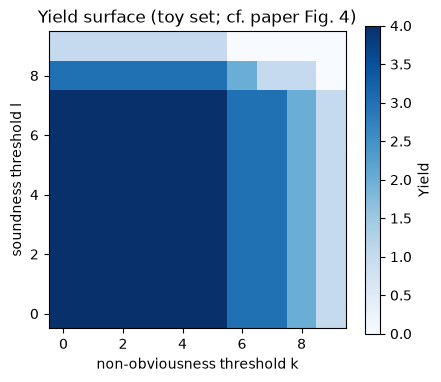

successful-topic ratio at Φ=2 over yields [2,0,3,1]: 0.5 | CST (eq. 7) with $5/topic: 10.0


In [23]:
show_source(X.yield_count)
nb = [7, 8, 6, 9, 5, 8]; s = [7, 7, 8, 7, 9, 8]; c = [6, 7, 6, 6, 6, 7]
pairs = {(0, 1): 8, (0, 2): 3, (0, 3): 7, (0, 4): 9, (0, 5): 7, (1, 2): 9, (1, 3): 2, (1, 4): 9, (1, 5): 1, (2, 3): 7, (2, 4): 9, (2, 5): 8, (3, 4): 9, (3, 5): 7, (4, 5): 9}
y, idx = X.yield_count(nb, s, c, pairs, k=6, l=7, m=6, tau=7)
print(f"toy set of 6 ideas: Yield(NB≥6,S≥7,C≥6,D≥7) = {y}, clique = {idx}  (idea 4 fails NB, ideas 1&5 are near-clones)")
surf = X.yield_surface(nb, s, c, pairs, k_values=range(0, 10), l_values=range(0, 10), m=6, tau=7)
fig, ax = plt.subplots(figsize=(4.8, 4)); im = ax.imshow(surf, origin="lower", cmap="Blues"); plt.colorbar(im, label="Yield")
ax.set(xlabel="non-obviousness threshold k", ylabel="soundness threshold l", title="Yield surface (toy set; cf. paper Fig. 4)"); plt.show()
print("successful-topic ratio at Φ=2 over yields [2,0,3,1]:", X.successful_topics([2, 0, 3, 1], 2), "| CST (eq. 7) with $5/topic:", X.cst([5, 5, 5, 5], [2, 0, 3, 1], 2))

## 14 · Greedy max–min topic selection (Alg. 1) — *not in the repo*

Topic names are embedded, the most isolated topic seeds the set, and the topic least similar to anything already selected is added until the budget Γ is reached. Embeddings via OpenRouter if an embedding model is available, else TF-IDF.

In [24]:
show_source(X.greedy_maxmin_topics)
names = [f"{t.get('topic_name', t['topic_id'])} ({t['domain_id']})" for t in TOPICS]
E = X.openrouter_embed(names)
E = E if E is not None else X.tfidf_embed(names)
sel = X.greedy_maxmin_topics(E, budget=6)
print("Γ=6 selected topics, in order:"); [print("  ", names[i]) for i in sel]
S_ = (E / np.linalg.norm(E, axis=1, keepdims=True)) @ (E / np.linalg.norm(E, axis=1, keepdims=True)).T
print("max pairwise cosine among selected:", round(max(S_[i, j] for a, i in enumerate(sel) for j in sel[a+1:]), 3), "| among all topics:", round(max(S_[i, j] for i in range(len(names)) for j in range(i+1, len(names))), 3))

**greedy_maxmin_topics**

```python
def greedy_maxmin_topics(embeddings: np.ndarray, budget: int) -> list[int]:
    """Greedy max–min selection over cosine similarities (paper Alg. 1).

    Seed = the most isolated topic (lowest mean similarity to the others); then repeatedly add the
    topic whose maximum similarity to the selected set is smallest."""
    E = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    S = E @ E.T
    n = len(S)
    mean_sim = (S.sum(1) - 1.0) / (n - 1)
    selected = [int(np.argmin(mean_sim))]
    remaining = set(range(n)) - set(selected)
    while len(selected) < min(budget, n):
        i_star = min(remaining, key=lambda i: max(S[i, j] for j in selected))
        selected.append(int(i_star))
        remaining.remove(i_star)
    return selected

```

Γ=6 selected topics, in order:
   Geometry and Linearity of Weight Space (cs.LG)
   End-to-End Autonomous Driving (cs.RO)
   Efficient Attention Mechanisms and KV Cache Optimization (cs.CL)
   Controllable Text-to-Image Synthesis and Editing (cs.CV)
   RL and Search for LLM Reasoning (cs.SE)
   Unifying Diffusion and Flow-Based Generative Models (cs.LG)
max pairwise cosine among selected: 0.369 | among all topics: 1.0


## 15 · End-to-end IDEAgent on two topics (Sec. 3.3, Sec. 6.1)

`GenerationLoop.run_topic` is the repo's full controller (Stage I generate → Stage II route/repair → Stage III refine). The paper's primary configuration is $B=10$ fresh seeds, $C_\mathcal{A}=10$, $K_{\text{aux}}=2$ auxiliary drafts per seed (≤1 repair, ≤2 accepted refinements), $M=5$ soundness samples; this run uses **B = 5, C_A = 5, K_aux = 2, M = 5 on two topics from different domains** (QUICK: one topic, B = 2, M = 3). The two topic searches are independent, so they run in parallel threads — the search *within* a topic stays strictly sequential (eq. 3). Every candidate line below is prefixed with its topic id.

In [25]:
B      = 2 if QUICK else 5      # discovery budget: fresh seeds
CAP    = 3 if QUICK else 5      # C_A: active archive capacity
KAUX   = 1 if QUICK else 2      # K_aux: auxiliary drafts per seed (repair + refinement share it)
RUN_TOPICS = [TOPIC] if QUICK else [TOPIC, TOPIC2]
RUN_DIR = OUT / "run"

def make_cfg(topic_id):
    return Config(input_jsonl=TOPIC_PATH, output_dir=str(RUN_DIR / topic_id), max_budget=B, soundness_n=SOUND_N,
                  soundness_fatal_min_votes=(SOUND_N // 2) + 1, diversity_D=60, accepted_capacity=CAP,
                  repair_capacity=1, repair_attempt_limit=1, accepted_refinement_limit=1 if QUICK else 2,
                  auxiliary_attempt_limit=KAUX, consolidate_every=12)

def make_loop(topic_id):
    "One full set of role clients per topic so the two searches never share mutable agent state."
    i_, ik_ = X.make_client(max_new_tokens=5000, tag="ideator")
    c_, ck_ = X.make_client(max_new_tokens=2500, tag="critic")
    q_, qk_ = X.make_client(max_new_tokens=3000, tag="quality+soundness")
    s_, sk_ = X.make_client(max_new_tokens=1024, tag="steno")
    j_, jk_ = X.make_client(max_new_tokens=2048, tag="judge")
    return GenerationLoop(config=make_cfg(topic_id), ideator=IdeatorAgent(role="ideator", client=i_, gen_kwargs=ik_),
                          critic=CriticAgent(role="critic", client=c_, gen_kwargs=ck_),
                          quality=QualityAgent(role="quality", client=q_, gen_kwargs=qk_),
                          steno_client=s_, steno_gen_kwargs=sk_, judge_client=j_, judge_gen_kwargs=jk_)

LOOPS = {t["topic_id"]: make_loop(t["topic_id"]) for t in RUN_TOPICS}
GEN_COST, GEN_CALLS, GEN_SECS = {}, {}, {}
def probe(): return (USAGE.cost_usd, USAGE.requests, time.time())
def record(name, p):
    GEN_COST[name] = USAGE.cost_usd - p[0]; GEN_CALLS[name] = USAGE.requests - p[1]; GEN_SECS[name] = time.time() - p[2]
    print(f"[{name}] {GEN_CALLS[name]} LLM calls, ${GEN_COST[name]:.4f}, {GEN_SECS[name]:.0f}s")
print("topics:", [t["topic_id"] for t in RUN_TOPICS], "| B =", B, "| C_A =", CAP, "| K_aux =", KAUX, "| M =", SOUND_N)

topics: ['cs.AI-002', 'cs.RO-005'] | B = 5 | C_A = 5 | K_aux = 2 | M = 5


In [26]:
p = probe()
RES = X.run_topics_parallel([{"topic_id": t["topic_id"], "loop": LOOPS[t["topic_id"]], "background": BG[t["topic_id"]],
                              "out_dir": RUN_DIR / t["topic_id"]} for t in RUN_TOPICS], workers=len(RUN_TOPICS))
record("IDEAgent", p)

[cs.RO-005 g001] free          nb= 80 cl= 65 snd= 55.6 div=100 -> repair_queued    ACTIVE=0 DISC=0 (repair=1)


[cs.AI-002 g001] free          nb= 70 cl= 65 snd= 31.1 div=100 -> reject_unsound   ACTIVE=0 DISC=0 (repair=0)


[cs.RO-005 g002.r1] repair        nb= 75 cl= 65 snd= 71.1 div=100 -> accepted         ACTIVE=1 DISC=1 (repair=0)


[cs.RO-005 g003.r2] accepted_refine nb= 80 cl= 60 snd= 48.9 div=100 -> keep_accepted    ACTIVE=1 DISC=1 (repair=0)


[cs.AI-002 g002] free          nb= 75 cl= 80 snd= 55.6 div= 75 -> repair_queued    ACTIVE=0 DISC=0 (repair=1)


...

[cs.RO-005 g009] pivot         nb= 90 cl= 65 snd= 24.4 div= 95 -> reject_unsound   ACTIVE=1 DISC=1 (repair=0)


[cs.AI-002 g008] free          nb= 85 cl= 88 snd= 64.4 div= 85 -> accepted         ACTIVE=2 DISC=2 (repair=0)


[cs.AI-002 g009.r1] accepted_refine nb= 45 cl= 90 snd= 77.8 div= 65 -> keep_accepted    ACTIVE=2 DISC=2 (repair=0)


[cs.AI-002 g010.r1] accepted_refine nb= 40 cl= 45 snd= 68.9 div= 15 -> keep_accepted    ACTIVE=2 DISC=2 (repair=0)


[IDEAgent] 180 LLM calls, $0.0792, 1129s


In [27]:
IDEAS = {}
rows = []
for t in RUN_TOPICS:
    tid = t["topic_id"]; arch, secs = RES[tid]
    ideas = [c.idea_text for c in arch.accepted.values()] or [c.idea_text for c in LOOPS[tid].last_lineage_representatives]
    IDEAS.setdefault("IDEAgent", {})[tid] = ideas
    st = arch.stats()
    rows.append({"topic": tid, "wall s": round(secs), "final ideas": len(ideas), **{k: st[k] for k in
                 ("free_generations_completed", "total_candidates_evaluated", "auxiliary_candidates_evaluated", "active_yield", "discovery_yield", "historical_qualified")},
                 "actions": arch.action_counts})
    details(f"archive.to_json() — final archive for {tid}", jdump(arch.to_json(), 8000))
display(df(rows).set_index("topic"))

,wall s,final ideas,free_generations_completed,total_candidates_evaluated,auxiliary_candidates_evaluated,active_yield,discovery_yield,historical_qualified,actions
topic,,,,,,,,,
cs.AI-002,1129,2,5,10,5,2,2,1,"{'free': 5, 'pivot': 0, 'repair': 1, 'novelty_..."
cs.RO-005,926,1,5,9,4,1,1,2,"{'free': 4, 'pivot': 1, 'repair': 2, 'novelty_..."


## 16 · Baselines (Sec. 6.2)

All three are prompt-matched to IDEAgent's Ideator (same `IDEATOR_SYSTEM_PROMPT`, same free-generation operator with judgment-neutral memory labels) and produce the same candidate budget B, but have no critic, evaluator, archive, repair or refinement:

* **Stateless** — B fully independent calls, no cross-idea signal at all (`op_free_baseline([])` every time).
* **Sequential-Memory (SM)** — B calls, each seeing the **cumulative compact signatures** σ(i) of every earlier idea and nothing else. This is the paper's candidate-budget-matched control and the strongest baseline in Table 1; run here through the repo's own `run_sequential_memory_baseline`.
* **One-Shot (OS)** — all B ideas in **one** call, with the repo's `single_shot_directive` and its `minItems == maxItems == B` JSON schema.

QUICK mode runs Stateless only.

In [28]:
from concurrent.futures import ThreadPoolExecutor
p = probe()
IDEAS["Stateless"] = {}
for t in RUN_TOPICS:
    bc, bkw = X.make_client(max_new_tokens=5000, tag="ideator")
    IDEAS["Stateless"][t["topic_id"]] = X.stateless_baseline(BG[t["topic_id"]], B, bc, bkw)
    print(f"Stateless {t['topic_id']}: {len(IDEAS['Stateless'][t['topic_id']])} ideas")
record("Stateless", p)

Stateless cs.AI-002: 5 ideas


Stateless cs.RO-005: 5 ideas
[Stateless] 10 LLM calls, $0.0145, 121s


In [29]:
if not QUICK:
    p = probe()
    def _sm(t):
        gc_, gk_ = X.make_client(max_new_tokens=5000, tag="ideator")
        sc_, sk_ = X.make_client(max_new_tokens=1024, tag="steno")
        return t["topic_id"], X.sequential_memory_baseline(
            input_jsonl=TOPIC_PATH, topic_idx=TOPIC_IDX[t["topic_id"]], B=B, client=gc_, gen_kwargs=gk_,
            steno_client=sc_, steno_gen_kwargs=sk_, out_dir=OUT / "baseline_sm" / t["topic_id"])
    with ThreadPoolExecutor(max_workers=len(RUN_TOPICS)) as ex:
        IDEAS["Sequential-Memory"] = dict(ex.map(_sm, RUN_TOPICS))
    record("Sequential-Memory", p)
    print({k: len(v) for k, v in IDEAS["Sequential-Memory"].items()})
else:
    print("QUICK: Sequential-Memory baseline skipped")


=== Sequential compact-memory baseline — topic cs.RO-005: 5 generator calls ===



=== Sequential compact-memory baseline — topic cs.AI-002: 5 generator calls ===


  idea 1/5: compact-memory entries=1


  idea 2/5: compact-memory entries=2


  idea 1/5: compact-memory entries=1


...

--- topic cs.RO-005: generated 5/5 ideas ---


  idea 4/5: compact-memory entries=4


  idea 5/5: compact-memory entries=5


--- topic cs.AI-002: generated 5/5 ideas ---


[Sequential-Memory] 20 LLM calls, $0.0111, 192s
{'cs.AI-002': 5, 'cs.RO-005': 5}


In [30]:
if not QUICK:
    p = probe()
    def _os(t):
        oc_, ok_ = X.make_client(max_new_tokens=10000, tag="ideator")
        ideas, note = X.one_shot_baseline(BG[t["topic_id"]], B, oc_, ok_)
        print(f"One-Shot {t['topic_id']}: {len(ideas)} ideas ({note})")
        return t["topic_id"], ideas
    with ThreadPoolExecutor(max_workers=len(RUN_TOPICS)) as ex:
        IDEAS["One-Shot"] = dict(ex.map(_os, RUN_TOPICS))
    record("One-Shot", p)
else:
    print("QUICK: One-Shot baseline skipped")
METHODS = [m for m in ("IDEAgent", "Sequential-Memory", "One-Shot", "Stateless") if m in IDEAS]
print("methods to evaluate:", METHODS, "| ideas per method:", {m: {k: len(v) for k, v in IDEAS[m].items()} for m in METHODS})

One-Shot cs.AI-002: 5 ideas (schema-parsed)


One-Shot cs.RO-005: 5 ideas (schema-parsed)
[One-Shot] 2 LLM calls, $0.0041, 142s
methods to evaluate: ['IDEAgent', 'Sequential-Memory', 'One-Shot', 'Stateless'] | ideas per method: {'IDEAgent': {'cs.AI-002': 2, 'cs.RO-005': 1}, 'Sequential-Memory': {'cs.AI-002': 5, 'cs.RO-005': 5}, 'One-Shot': {'cs.AI-002': 5, 'cs.RO-005': 5}, 'Stateless': {'cs.AI-002': 5, 'cs.RO-005': 5}}


## 17 · Table-1-style comparison under the external judges (Sec. 5, Table 1, eq. 7)

Every method's idea set is scored by the *same* external protocol, independent of anything used during generation: five 0–9 quality rubrics per idea (non-obviousness, soundness, mechanism clarity, feasibility, significance — Tables 6–10) and the eight-axis pairwise distinctness $D_{ij}\in\{0..9\}$ (Table 4/11), averaged per topic as $D(T)=\binom{N}{2}^{-1}\sum_{i<j}D_{ij}$ (eq. 6). Yield uses the paper's gate $(l,m,\tau)=(7,6,7)$ at $k\in\{6,7\}$; CST divides each method's own generation cost (from this notebook's usage tracker) by its number of successful topics. All method × topic evaluations run concurrently.

In [31]:
eqc, eqkw = X.make_client(max_new_tokens=3000, tag="eval-quality")
ejc, ejkw = X.make_client(max_new_tokens=3000, tag="eval-diversity")
jobs = [(m, t["topic_id"]) for m in METHODS for t in RUN_TOPICS]
t0 = time.time()
with ThreadPoolExecutor(max_workers=min(4, len(jobs))) as ex:
    futs = {ex.submit(X.score_idea_set, m, tid, IDEAS[m][tid], eqc, eqkw, ejc, ejkw, workers=4): (m, tid) for m, tid in jobs}
    SCORED = {}
    for f, (m, tid) in futs.items():
        SCORED.setdefault(m, {})[tid] = f.result()
RESULTS = {m: [SCORED[m][t["topic_id"]] for t in RUN_TOPICS] for m in METHODS}
print(f"external evaluation of {len(jobs)} (method, topic) sets in {time.time()-t0:.0f}s")
display(df([{"method": m, "topic": r["topic_id"], "N": r["n"],
             "NB": round(float(np.mean([r["quality"].get(i, {}).get("nonobviousness", 0) for i in range(r["n"])])), 2) if r["n"] else None,
             "S": round(float(np.mean([r["quality"].get(i, {}).get("soundness", 0) for i in range(r["n"])])), 2) if r["n"] else None,
             "C": round(float(np.mean([r["quality"].get(i, {}).get("mechanism_clarity_specificity", 0) for i in range(r["n"])])), 2) if r["n"] else None,
             "avg pairwise D": r["avg_pairwise"],
             "Yield(NB≥6)": X.topic_yield(r, k=6, l=7, m=6, tau=7), "Yield(NB≥7)": X.topic_yield(r, k=7, l=7, m=6, tau=7)}
            for m in METHODS for r in RESULTS[m]]).set_index(["method", "topic"]))

external evaluation of 8 (method, topic) sets in 686s


N   NB    S    C  avg pairwise D  Yield(NB≥6)  \
method            topic                                                      
IDEAgent          cs.AI-002  2  7.0  6.5  5.5             4.0            1   
                  cs.RO-005  1  5.0  7.0  9.0             NaN            0   
Sequential-Memory cs.AI-002  5  5.8  5.2  5.0             4.2            1   
                  cs.RO-005  5  5.6  5.8  4.4             5.7            1   
One-Shot          cs.AI-002  5  5.8  5.0  3.6             6.0            0   
                  cs.RO-005  5  4.8  4.2  3.4             6.3            0   
Stateless         cs.AI-002  5  6.2  6.0  4.4             5.7            1   
                  cs.RO-005  5  6.2  6.2  4.8             5.7            0   

                             Yield(NB≥7)  
method            topic                   
IDEAgent          cs.AI-002            1  
                  cs.RO-005            0  
Sequential-Memory cs.AI-002            1  
                  cs.RO-005            1  
One-Shot          cs.AI-002            0  
                  cs.RO-005            0  
Stateless         cs.AI-002            1  
                  cs.RO-005            0

In [32]:
TAB = df(X.table1(RESULTS, GEN_COST, ks=(7, 6), l=7, m=6, tau=7, phis=(1, 2))).set_index("metric")
display(TAB)
print("generation calls per method:", GEN_CALLS, "\nwall-clock seconds per method:", {k: round(v) for k, v in GEN_SECS.items()})

,IDEAgent,Sequential-Memory,One-Shot,Stateless
metric,,,,
"Yield(NB≥7, gate)",0.5,1.0,0.0,0.5
"Yield(NB≥6, gate)",0.5,1.0,0.0,0.5
Successful topics Yield(NB≥7)≥1,1/2,2/2,0/2,1/2
Successful topics Yield(NB≥7)≥2,0/2,0/2,0/2,0/2
Successful topics Yield(NB≥6)≥1,1/2,2/2,0/2,1/2
Successful topics Yield(NB≥6)≥2,0/2,0/2,0/2,0/2
Non-obviousness,6.333,5.7,5.3,6.2
Soundness,6.667,5.5,4.6,6.1
Mechanism clarity,6.667,4.7,3.5,4.6


generation calls per method: {'IDEAgent': 180, 'Stateless': 10, 'Sequential-Memory': 20, 'One-Shot': 2} 
wall-clock seconds per method: {'IDEAgent': 1129, 'Stateless': 121, 'Sequential-Memory': 192, 'One-Shot': 142}


## 18 · Yield surface over the quality thresholds (Fig. 2 / Fig. 4)

The Yield surface is the same Alg. 2 computation over a grid of non-obviousness ($k$) and soundness ($l$) thresholds at fixed $C\ge 6$, $D\ge 7$, averaged over topics. The paper's zoomed view (Fig. 2) is $k\in[6,7]$, $l\in[6,8]$; the grid here is $k,l\in\{5,6,7,8\}$ from *this* run's external-judge scores.

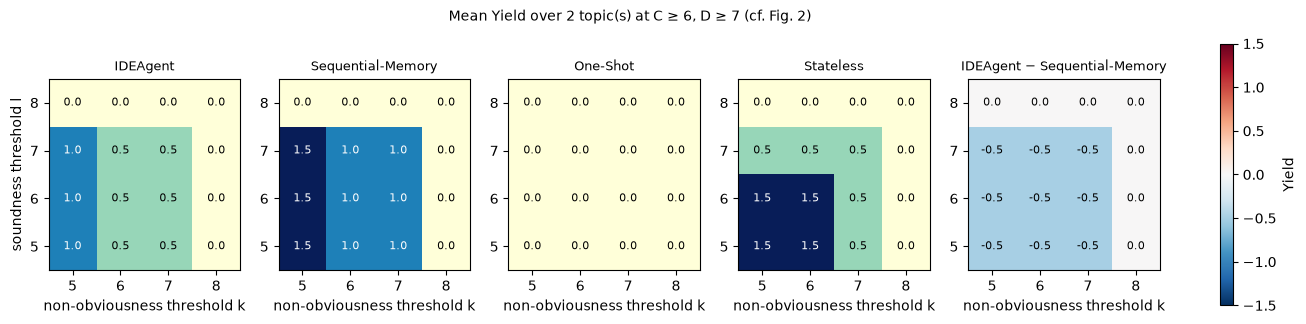

In [33]:
KS, LS = list(range(5, 9)), list(range(5, 9))
SURF = X.yield_surface_by_method(RESULTS, k_values=KS, l_values=LS, m=6, tau=7)
base = "Sequential-Memory" if "Sequential-Memory" in SURF else "Stateless"
panels = [(m, SURF[m], "YlGnBu") for m in METHODS] + ([("IDEAgent − " + base, SURF["IDEAgent"] - SURF[base], "RdBu_r")] if base in SURF else [])
vmax = max(1e-9, max(np.abs(g).max() for _, g, _ in panels))
fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 3.4), squeeze=False)
for ax, (name, grid, cmap) in zip(axes[0], panels):
    kw = dict(vmin=-vmax, vmax=vmax) if cmap == "RdBu_r" else dict(vmin=0, vmax=vmax)
    im = ax.imshow(grid, origin="lower", cmap=cmap, **kw)
    for i in range(len(LS)):
        for j in range(len(KS)):
            ax.text(j, i, f"{grid[i, j]:.1f}", ha="center", va="center", fontsize=8,
                    color="black" if abs(grid[i, j]) < 0.6 * vmax else "white")
    ax.set_xticks(range(len(KS)), KS); ax.set_yticks(range(len(LS)), LS)
    ax.set_xlabel("non-obviousness threshold k"); ax.set_title(name, fontsize=9)
axes[0][0].set_ylabel("soundness threshold l")
fig.suptitle(f"Mean Yield over {len(RUN_TOPICS)} topic(s) at C ≥ 6, D ≥ 7 (cf. Fig. 2)", fontsize=10)
plt.colorbar(im, ax=axes[0].tolist(), fraction=0.025, label="Yield"); plt.show()

## 19 · Lineage graph of the end-to-end run (Fig. 1, right)

Every candidate the controller evaluated is written to `candidates_<topic>.jsonl` with its parent, lineage, operator and archive outcome. Plotting that file directly reproduces the paper's picture of an evolving idea: free seeds start new lineages, repair/refinement children hang off their parent inside the same lineage, and the colour is the routing decision that ended each step.

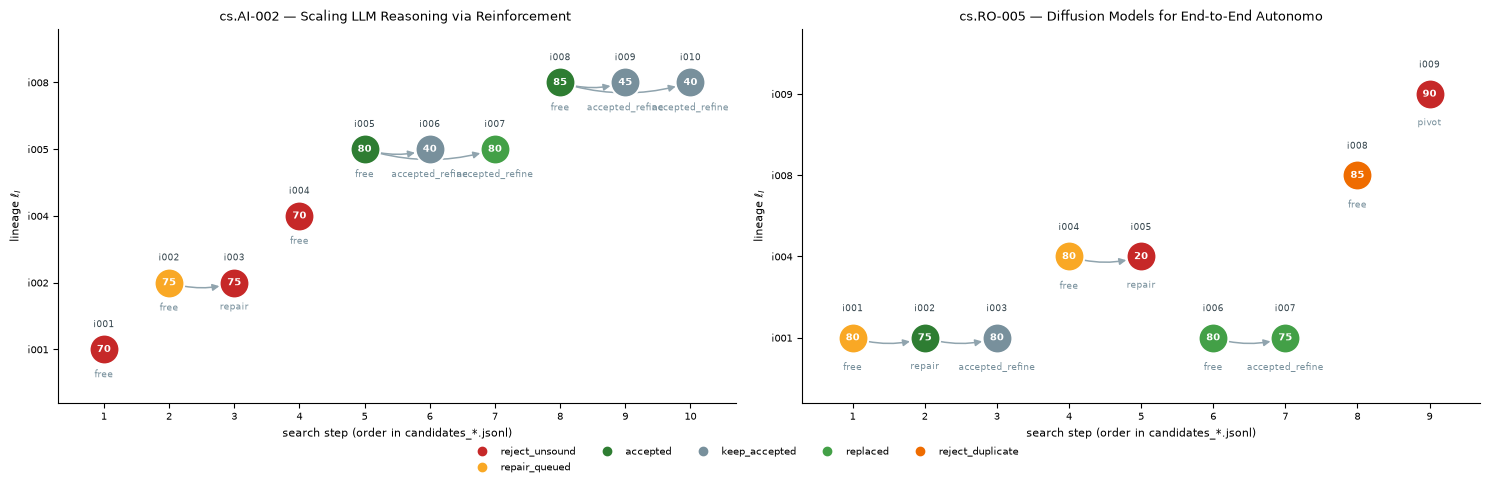

lineage               op parent  NB     S   C    D     Q_b  \
topic     id                                                                
cs.AI-002 i001    i001             free    NaN  70  31.1  65  100  61.722   
          i002    i002             free    NaN  75  55.6  80   75  71.611   
          i003    i002           repair   i002  75  60.0  75   90  72.000   
          i004    i004             free    NaN  70  35.6  75   95  57.222   
          i005    i005             free    NaN  80  62.2  75  100  71.889   
          i006    i005  accepted_refine   i005  40  68.9  70   85  57.556   
          i007    i005  accepted_refine   i005  80  66.7  85   85  75.667   
          i008    i008             free    NaN  85  64.4  88   85  77.378   
          i009    i008  accepted_refine   i008  45  77.8  90   65  67.111   
          i010    i008  accepted_refine   i008  40  68.9  45   15  52.556   
cs.RO-005 i001    i001             free    NaN  80  55.6  65  100  73.611   
          i002    i001           repair   i001  75  71.1  65  100  73.222   
          i003    i001  accepted_refine   i002  80  48.9  60  100  71.778   
          i004    i004             free    NaN  80  42.2  85   75  72.944   
          i005    i004           repair   i004  20  66.7  75   70  34.833   
          i006    i001             free    NaN  80  62.2  75    0  71.889   
          i007    i001  accepted_refine   i006  75  66.7  80   85  72.667   
          i008    i008             free    NaN  85  55.6  60   35  68.222   
          i009    i009            pivot    NaN  90  24.4  65   95  58.778   

                         outcome  \
topic     id                       
cs.AI-002 i001    reject_unsound   
          i002     repair_queued   
          i003    reject_unsound   
          i004    reject_unsound   
          i005          accepted   
          i006     keep_accepted   
          i007          replaced   
          i008          accepted   
          i009     keep_accepted   
          i010     keep_accepted   
cs.RO-005 i001     repair_queued   
          i002          accepted   
          i003     keep_accepted   
          i004     repair_queued   
          i005    reject_unsound   
          i006          replaced   
          i007          replaced   
          i008  reject_duplicate   
          i009    reject_unsound   

                                                           defect  
topic     id                                                       
cs.AI-002 i001                                                     
          i002  soundness 56<60: The mechanism is logically co...  
          i003  soundness panel dispute (1/5 severe votes <= 3...  
          i004                                                     
          i005                                                     
          i006                                                     
          i007                                                     
          i008                                                     
          i009                                                     
          i010                                                     
cs.RO-005 i001  soundness panel dispute (1/5 severe votes <= 3...  
          i002                                                     
          i003                                                     
          i004  soundness panel dispute (2/5 severe votes <= 3...  
          i005                                                     
          i006                                                     
          i007                                                     
          i008                                                     
          i009

In [34]:
paths = [RUN_DIR / t["topic_id"] / f"candidates_{t['topic_id']}.jsonl" for t in RUN_TOPICS]
fig = X.lineage_graph(paths, [f"{t['topic_id']} — {t.get('topic_name','')[:40]}" for t in RUN_TOPICS],
                      figsize=(7.5 * len(paths), 4.6))
plt.show()
rows = []
for t, p in zip(RUN_TOPICS, paths):
    for r in [json.loads(l) for l in p.read_text().splitlines() if l.strip()]:
        rows.append({"topic": t["topic_id"], "id": r["id"], "lineage": r["lineage_id"], "op": r["operator"], "parent": r["parent_id"],
                     "NB": r["non_obviousness"], "S": r["soundness_100"], "C": r["mechanism_clarity"], "D": r["diversity_score"],
                     "Q_b": r["weighted_quality"], "outcome": r["outcome"], "defect": (r["defect"] or "")[:60]})
display(df(rows).set_index(["topic", "id"]))

## Summary

| Block | Result of this run |
|---|---|
| Corpus / context | 32 shipped topics; two topics' 5–8 papers rendered into the Ideator context |
| Stage flow | Fig. 1 (left) redrawn from the repo's own thresholds and routing cases |
| Ideator, Stenographer, Quality, Soundness, Diversity | each called in isolation on the same idea; full artefacts (idea markdown, signature JSON, rubric JSON, panel rationales, diversity verdicts) dumped inline |
| Gate G + routing | every Stage II branch reproduced on edited candidates, with the archive snapshot after each case |
| Q_b + replacement | capacity eviction by weighted quality, displaced idea kept in H |
| Repair (API) | critic challenge → same-lineage child → re-evaluation → `Archive.consider(repair_parent=…)` |
| Repair (pi agent) | the same Stage-II subroutine driven by a live coding agent over files, routed through the same archive code; side-by-side table in §11 |
| Refinement | blinded position-swapped NB check, both judgments shown |
| Yield / topics | Alg. 2 and Alg. 1 re-implemented; exact max clique from the repo |
| End-to-end | B=5, C_A=5, K_aux=2, M=5 on two topics, run concurrently |
| Baselines | Stateless, Sequential-Memory (repo code) and One-Shot (repo prompt + schema) at the same budget |
| Table 1 / Fig. 2 | Yield at two gates, successful topics at Φ=1,2, five rubrics, pairwise diversity, CST, and the Yield surface — all from the same external judge |
| Lineage graph | Fig. 1 (right) drawn from `candidates_<topic>.jsonl` |

Scale caveat: two topics and B=5 (vs 32 topics and B=10 in the paper) with a single small judge model, so the numbers are indicative, not a reproduction of Table 1.

In [35]:
print(USAGE.summary())

575 requests, 1919161 in / 223674 out tokens, 8731s in model calls, $0.2186; by tag: {'critic': 11, 'eval-diversity': 154, 'eval-quality': 165, 'ideator': 46, 'judge': 19, 'pi-repair': 1, 'quality+soundness': 144, 'steno': 35}
